# 05 — Explainability (SHAP)
**Goal:** Explain individual predictions from fh_rsl_classifier and sanity_classifier,
not just output a label.

1. Setup — reload models and data

In [7]:
import sys
from pathlib import Path
sys.path.append(str(Path("../src").resolve()))
from explainability.explain_fh_rsl import explain_prediction

In [8]:
import pandas as pd
import joblib
import shap
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")

rf_fh = joblib.load(MODELS_DIR / "fh_rsl_classifier.pkl")
rf_sanity = joblib.load(MODELS_DIR / "sanity_classifier.pkl")

df_fh = pd.read_csv(PROCESSED_DIR / "fh_rsl_features.csv")
df_sanity = pd.read_csv(PROCESSED_DIR / "sanity_features.csv")

feature_cols_fh = ["Max RSL", "RSL REF", "RSL DIFF", "Max RSL_was_sentinel"]
feature_cols_sanity = [
    "RSL (Min)", "RSL (Max)", "RSL (Avg)", "rsl_range",
    "UAS", "SEP", "SES", "ES", "BBE", "OFS",
    "RSL (Min)_was_sentinel", "RSL (Max)_was_sentinel", "RSL (Avg)_was_sentinel",
]

X_fh = df_fh[feature_cols_fh].fillna(df_fh[feature_cols_fh].median())
X_sanity = df_sanity[feature_cols_sanity].fillna(df_sanity[feature_cols_sanity].median())

print("loaded OK")

loaded OK


2.SHAP for fh_rsl_classifier — global summary first (which features matter overall, per class)

In [9]:
explainer_fh = shap.TreeExplainer(rf_fh)
shap_values_fh = explainer_fh.shap_values(X_fh)

print(type(shap_values_fh))
print(len(shap_values_fh) if isinstance(shap_values_fh, list) else shap_values_fh.shape)

<class 'numpy.ndarray'>
(1292, 4, 3)


In [10]:
class_names = rf_fh.classes_
print("classes:", class_names)

for i, cls in enumerate(class_names):
    print(f"\n--- mean |SHAP value| for class: {cls} ---")
    mean_abs_shap = pd.Series(
        abs(shap_values_fh[:, :, i]).mean(axis=0), index=feature_cols_fh
    ).sort_values(ascending=False)
    print(mean_abs_shap)

classes: ['Lien_OK' 'Lien_dépointé_(<10)' 'Lien_dépointé_(>10)']

--- mean |SHAP value| for class: Lien_OK ---
RSL DIFF                0.486565
RSL REF                 0.045079
Max RSL                 0.030806
Max RSL_was_sentinel    0.003049
dtype: float64

--- mean |SHAP value| for class: Lien_dépointé_(<10) ---
RSL DIFF                0.360068
RSL REF                 0.021532
Max RSL                 0.019294
Max RSL_was_sentinel    0.000582
dtype: float64

--- mean |SHAP value| for class: Lien_dépointé_(>10) ---
RSL DIFF                0.304138
RSL REF                 0.054677
Max RSL                 0.033517
Max RSL_was_sentinel    0.003452
dtype: float64


In [11]:
# find a row predicted as the worst category
predictions = rf_fh.predict(X_fh)
degraded_idx = df_fh[predictions == "Lien_dépointé_(>10)"].index[0]

print("--- example row ---")
print(df_fh.loc[degraded_idx, ["Status"] + feature_cols_fh])

class_idx = list(class_names).index("Lien_dépointé_(>10)")
print(f"\n--- SHAP contribution to 'Lien_dépointé_(>10)' prediction ---")
contributions = pd.Series(
    shap_values_fh[degraded_idx, :, class_idx], index=feature_cols_fh
).sort_values(ascending=False)
print(contributions)

--- example row ---
Status                  Lien_OK
Max RSL                     NaN
RSL REF                   -35.0
RSL DIFF                    NaN
Max RSL_was_sentinel       True
Name: 71, dtype: object

--- SHAP contribution to 'Lien_dépointé_(>10)' prediction ---
Max RSL_was_sentinel    0.220728
RSL REF                 0.160515
Max RSL                 0.002508
RSL DIFF               -0.126496
dtype: float64


In [12]:
predictions = rf_fh.predict(X_fh)
correct_and_real = df_fh[
    (predictions == "Lien_dépointé_(>10)") &
    (df_fh["Status"] == "Lien_dépointé_(>10)") &
    (df_fh["Max RSL_was_sentinel"] == False)
]
degraded_idx = correct_and_real.index[0]

print("--- example row ---")
print(df_fh.loc[degraded_idx, ["Status"] + feature_cols_fh])

class_idx = list(class_names).index("Lien_dépointé_(>10)")
print(f"\n--- SHAP contribution to 'Lien_dépointé_(>10)' prediction ---")
contributions = pd.Series(
    shap_values_fh[degraded_idx, :, class_idx], index=feature_cols_fh
).sort_values(ascending=False)
print(contributions)

--- example row ---
Status                  Lien_dépointé_(>10)
Max RSL                               -57.8
RSL REF                               -22.2
RSL DIFF                               35.6
Max RSL_was_sentinel                  False
Name: 246, dtype: object

--- SHAP contribution to 'Lien_dépointé_(>10)' prediction ---
RSL DIFF                0.543828
Max RSL                 0.135680
Max RSL_was_sentinel   -0.000467
RSL REF                -0.011786
dtype: float64


In [13]:
import sys
sys.path.append(str(Path("../src").resolve()))
from explainability.explain_fh_rsl import explain_prediction

example_row = df_fh.loc[degraded_idx]
explanation = explain_prediction(rf_fh, example_row, feature_cols_fh)
print(explanation)

Predicted status: Lien_dépointé_(>10). Main driver(s): the signal difference from reference (RSL DIFF) (value: 35.6) and the received signal level (Max RSL) (value: -57.8).


In [14]:
import sys
from pathlib import Path
sys.path.append(str(Path("../src").resolve()))
from explainability.explain_sanity import explain_prediction as explain_sanity

predictions_sanity = rf_sanity.predict(X_sanity)
curative_idx = df_sanity[
    (predictions_sanity == "CURATIVE") & (df_sanity["Sanity"] == "CURATIVE")
].index[0]

example_row_sanity = df_sanity.loc[curative_idx]
explanation_sanity = explain_sanity(rf_sanity, example_row_sanity, feature_cols_sanity)
print(explanation_sanity)

Predicted sanity: CURATIVE. Main driver(s): out-of-frame seconds (OFS) (value: 95) and the minimum received signal level (value: -93.8) and unavailable seconds (UAS) (value: 691200).


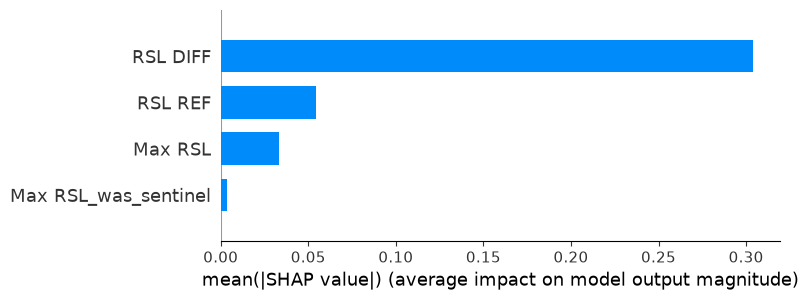

In [15]:
shap.summary_plot(shap_values_fh[:, :, 2], X_fh, feature_names=feature_cols_fh,
                   show=True, plot_type="bar")